In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
def get_hand_line(p1, p2, segments=10, wobble=2):
    """Crea una linea con piccole imperfezioni casuali."""
    x_vals = np.linspace(p1[0], p2[0], segments)
    y_vals = np.linspace(p1[1], p2[1], segments)
    x_vals += np.random.uniform(-wobble, wobble, segments)
    y_vals += np.random.uniform(-wobble, wobble, segments)
    x_vals[0], y_vals[0] = p1
    x_vals[-1], y_vals[-1] = p2
    return x_vals, y_vals

def draw_letter(ax, char, x, y, size, color, weight):
    """Disegna le lettere G, T, B, Y con tratti naturali."""
    s = size * 0.35 
    w = weight + random.uniform(-0.5, 0.5)
    paths = []
    
    if char == 'G':
        # Arco della G
        t = np.linspace(0.2 * np.pi, 1.9 * np.pi, 25)
        arc_x = x + s * np.cos(t)
        arc_y = y + s * np.sin(t)
        paths.append((arc_x, arc_y))
        # Stangetta collegata alla fine dell'arco
        start_pt = (arc_x[-1], arc_y[-1])
        end_pt = (x, y + random.uniform(-s*0.1, s*0.1))
        paths.append(get_hand_line(start_pt, end_pt, segments=5, wobble=1))
        
    elif char == 'T':
        y_top = y + s + random.uniform(-1, 1)
        paths.append(get_hand_line((x - s, y_top), (x + s, y + s), segments=5, wobble=1))
        paths.append(get_hand_line((x, y + s), (x + random.uniform(-2, 2), y - s), segments=5, wobble=1))
        
    elif char == 'B':
        v_x = x - s + random.uniform(-1, 1)
        paths.append(get_hand_line((v_x, y + s), (v_x, y - s), segments=5, wobble=1.5))
        t = np.linspace(-np.pi/2, np.pi/2, 12)
        paths.append((v_x + s * np.cos(t), y + s/2 + s/2 * np.sin(t)))
        paths.append((v_x + s * np.cos(t), y - s/2 + s/2 * np.sin(t)))
        
    elif char == 'Y':
        joint = (x + random.uniform(-2, 2), y + random.uniform(-2, 2))
        paths.append(get_hand_line((x - s, y + s), joint, segments=5, wobble=1))
        paths.append(get_hand_line((x + s, y + s), joint, segments=5, wobble=1))
        paths.append(get_hand_line(joint, (joint[0], y - s), segments=5, wobble=1))

    for px, py in paths:
        ax.plot(px, py, color=color, lw=w, solid_capstyle='round', alpha=0.9)

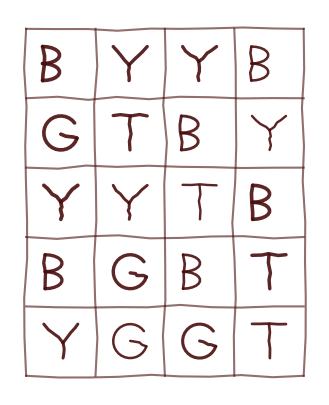

In [3]:
# 1. Parametri casuali per questa specifica esecuzione
rows, cols = random.randint(2, 6), random.randint(2, 6)
cell_size = 50
ink_color = random.choice(['#000000', '#1e1e1e', '#002b5b', '#4a0e0e'])
bg_color = random.choice(['#ffffff', '#fffaf0', '#f8f9fa'])

# 2. Setup del grafico
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor(bg_color)

# 3. Disegno della griglia "a mano"
w_grid = random.uniform(1.0, 2.5)
for i in range(rows + 1):
    ax.plot(*get_hand_line((0, i*cell_size), (cols*cell_size, i*cell_size), wobble=1.5), color=ink_color, lw=1.5, alpha=0.6)
for j in range(cols + 1):
    ax.plot(*get_hand_line((j*cell_size, 0), (j*cell_size, rows*cell_size), wobble=1.5), color=ink_color, lw=1.5, alpha=0.6)

# 4. Riempimento casuale
for r in range(rows):
    for c in range(cols):
        char = random.choice(['G', 'T', 'B', 'Y'])
        draw_letter(ax, char, c*cell_size + cell_size/2, r*cell_size + cell_size/2, cell_size*0.7, ink_color, 2.2)

plt.show()